In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
baseDP = pd.read_csv("C:/Users/conta/Desktop/Projeto-Dash-PY-JS/BaseDPEvolucaoMensalCisp.csv", sep=";", encoding='Latin1')

In [24]:
baseDP.isna().sum()

cisp                         0
mes                          0
ano                          0
mes_ano                      0
aisp                         0
                            ..
encontro_ossada              0
pol_militares_mortos_serv    0
pol_civis_mortos_serv        0
registro_ocorrencias         0
fase                         0
Length: 63, dtype: int64

In [25]:
baseDP.isna().sum()

cisp                         0
mes                          0
ano                          0
mes_ano                      0
aisp                         0
                            ..
encontro_ossada              0
pol_militares_mortos_serv    0
pol_civis_mortos_serv        0
registro_ocorrencias         0
fase                         0
Length: 63, dtype: int64

In [26]:
baseDP.head(10)

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
5,9,1,2003,2003m01,2,1,Rio de Janeiro,3304557,Capital,1,...,NaN,NaN,36,3,0,0,0,0,554,3
6,10,1,2003,2003m01,2,1,Rio de Janeiro,3304557,Capital,1,...,NaN,NaN,40,2,3,0,0,0,593,3
7,12,1,2003,2003m01,19,1,Rio de Janeiro,3304557,Capital,2,...,NaN,NaN,48,3,0,0,0,0,620,3
8,13,1,2003,2003m01,19,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,26,1,0,0,0,0,455,3
9,14,1,2003,2003m01,23,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,43,2,2,0,0,0,636,3


In [27]:
baseDP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35670 entries, 0 to 35669
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        35670 non-null  int64  
 1   mes                         35670 non-null  int64  
 2   ano                         35670 non-null  int64  
 3   mes_ano                     35670 non-null  object 
 4   aisp                        35670 non-null  int64  
 5   risp                        35670 non-null  int64  
 6   munic                       35670 non-null  object 
 7   mcirc                       35670 non-null  int64  
 8   regiao                      35670 non-null  object 
 9   hom_doloso                  35670 non-null  int64  
 10  lesao_corp_morte            35670 non-null  int64  
 11  latrocinio                  35670 non-null  int64  
 12  cvli                        35670 non-null  int64  
 13  hom_por_interv_policial     356

In [28]:
baseDP['mes_ano'] = baseDP['mes_ano'].astype(str).str.replace('m', '-')

In [29]:
baseDP2 = baseDP

In [30]:
baseDP['ano'] = pd.to_datetime(baseDP['ano'], format='%Y')
baseDP['mes_ano'] = pd.to_datetime(baseDP['mes_ano'], format='%Y-%m')

In [31]:
baseDP['ano'] = baseDP['ano'].dt.year

In [32]:
baseDP = baseDP.drop(columns=['cmp', 'mes', 'total_furtos', 'total_roubos'])

In [33]:
baseDP['Todos_roubos'] = baseDP[['roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua', 'roubo_veiculo', 'roubo_carga', 'roubo_residencia', 'roubo_comercio', 'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque', 'roubo_apos_saque', 'outros_roubos']].sum(axis=1)
baseDP['Todos_furtos'] = baseDP[['furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular', 'outros_furtos']].sum(axis=1)

In [34]:
baseDP.head(10)

,cisp,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,lesao_corp_morte,...,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,Todos_roubos,Todos_furtos
0,1,2003,2003-01-01,5,1,Rio de Janeiro,3304557,Capital,0,0,...,21,2,0,0,0,0,578,3,166.0,169
1,4,2003,2003-01-01,5,1,Rio de Janeiro,3304557,Capital,3,0,...,15,6,0,1,0,0,441,3,133.0,115
2,5,2003,2003-01-01,5,1,Rio de Janeiro,3304557,Capital,3,0,...,47,2,1,0,0,0,637,3,187.0,216
3,6,2003,2003-01-01,1,1,Rio de Janeiro,3304557,Capital,6,0,...,26,2,1,0,0,0,473,3,199.0,90
4,7,2003,2003-01-01,1,1,Rio de Janeiro,3304557,Capital,4,0,...,10,1,3,0,0,0,147,3,60.0,35
5,9,2003,2003-01-01,2,1,Rio de Janeiro,3304557,Capital,1,1,...,36,3,0,0,0,0,554,3,168.0,268
6,10,2003,2003-01-01,2,1,Rio de Janeiro,3304557,Capital,1,0,...,40,2,3,0,0,0,593,3,165.0,290
7,12,2003,2003-01-01,19,1,Rio de Janeiro,3304557,Capital,2,0,...,48,3,0,0,0,0,620,3,178.0,256
8,13,2003,2003-01-01,19,1,Rio de Janeiro,3304557,Capital,0,0,...,26,1,0,0,0,0,455,3,113.0,217
9,14,2003,2003-01-01,23,1,Rio de Janeiro,3304557,Capital,0,0,...,43,2,2,0,0,0,636,3,160.0,311


In [35]:
baseDP['Todos_roubos'] = baseDP['Todos_roubos'].astype(int)

In [36]:
baseDP['ano'] = pd.to_datetime(baseDP['ano'], format='%Y')

In [37]:
'''baseDP = pd.to_datetime(baseDP['mes_ano']).dt.month'''

"baseDP = pd.to_datetime(baseDP['mes_ano']).dt.month"

In [38]:
baseDP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35670 entries, 0 to 35669
Data columns (total 61 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cisp                        35670 non-null  int64         
 1   ano                         35670 non-null  datetime64[ns]
 2   mes_ano                     35670 non-null  datetime64[ns]
 3   aisp                        35670 non-null  int64         
 4   risp                        35670 non-null  int64         
 5   munic                       35670 non-null  object        
 6   mcirc                       35670 non-null  int64         
 7   regiao                      35670 non-null  object        
 8   hom_doloso                  35670 non-null  int64         
 9   lesao_corp_morte            35670 non-null  int64         
 10  latrocinio                  35670 non-null  int64         
 11  cvli                        35670 non-null  int64     

In [39]:
baseDP.head()

,cisp,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,lesao_corp_morte,...,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,Todos_roubos,Todos_furtos
0,1,2003-01-01,2003-01-01,5,1,Rio de Janeiro,3304557,Capital,0,0,...,21,2,0,0,0,0,578,3,166,169
1,4,2003-01-01,2003-01-01,5,1,Rio de Janeiro,3304557,Capital,3,0,...,15,6,0,1,0,0,441,3,133,115
2,5,2003-01-01,2003-01-01,5,1,Rio de Janeiro,3304557,Capital,3,0,...,47,2,1,0,0,0,637,3,187,216
3,6,2003-01-01,2003-01-01,1,1,Rio de Janeiro,3304557,Capital,6,0,...,26,2,1,0,0,0,473,3,199,90
4,7,2003-01-01,2003-01-01,1,1,Rio de Janeiro,3304557,Capital,4,0,...,10,1,3,0,0,0,147,3,60,35


In [40]:
'''Qual é a distribuição de crimes violentos (hom_doloso, lesao_corp_morte, latrocinio) ao longo dos meses (mes) e anos (ano)?'''

crimes_violentos = baseDP[['hom_doloso', 'lesao_corp_morte', 'latrocinio']]

resultado1 = crimes_violentos.groupby([baseDP['ano'], baseDP['mes_ano']]).sum()

print(resultado1)

                       hom_doloso  lesao_corp_morte  latrocinio
ano        mes_ano                                             
2003-01-01 2003-01-01         589                 6          20
           2003-02-01         583                 4          12
           2003-03-01         613                 5          16
           2003-04-01         585                11          14
           2003-05-01         599                 6          20
...                           ...               ...         ...
2024-01-01 2024-09-01         226                 7           8
           2024-10-01         230                 5          13
           2024-11-01         252                 5           9
           2024-12-01         304                13          10
2025-01-01 2025-01-01         312                10           6

[265 rows x 3 columns]


In [41]:
'''Há valores faltantes nas colunas de crimes violentos? Como tratá-los?'''
crimes_violentos.isna().sum()

hom_doloso          0
lesao_corp_morte    0
latrocinio          0
dtype: int64

In [42]:
'''Qual é a proporção de crimes contra o patrimônio (Todos_roubos, Todos_furtos) em relação aos crimes violentos?'''

soma_crimes_patrimonio = baseDP[['Todos_roubos', 'Todos_furtos']].sum().sum()

soma_crimes_violentos = baseDP[['hom_doloso', 'lesao_corp_morte', 'latrocinio']].sum().sum()

resultado2 = soma_crimes_patrimonio / soma_crimes_violentos

print(f'A proporção de crimes contra o patrimônio em relação aos crimes violentos é: {resultado2:.2f}')

A proporção de crimes contra o patrimônio em relação aos crimes violentos é: 74.05


In [43]:
'''Agrupe os dados por risp e calcule a média de hom_por_interv_policial. Qual risp tem a maior média?'''

media_hom_por_interv_policial = baseDP.groupby('risp')['hom_por_interv_policial'].mean()

risp_maior_media = media_hom_por_interv_policial.idxmax()
maior_media = media_hom_por_interv_policial.max()

print(f'A RISP com a maior média de hom_por_interv_policial é: {risp_maior_media} com uma média de {maior_media:.2f}')

A RISP com a maior média de hom_por_interv_policial é: 2 com uma média de 1.41


In [44]:
'''Agrupe os dados por munic e calcule a soma de furto_celular. Qual município tem o maior número de furto_celular?'''

soma_roubo_bic_munic = baseDP.groupby('munic')['furto_celular'].sum()

munic_mais_roubos = soma_roubo_bic_munic.idxmax()  #idxmax retorna o INDÍCE do maior valor

print(f'O município que tem o maior número de furto_celular é: {munic_mais_roubos}')

O município que tem o maior número de furto_celular é: Rio de Janeiro


In [45]:
'''Qual é o município (munic) com o maior número de homicídios dolosos (hom_doloso) em um ano específico?'''

ano_especifico = 2023
ano_filtro = baseDP2[baseDP['ano'] == ano_especifico]

soma_munic_hom_doloso = baseDP.groupby('munic')['hom_doloso'].sum()

munic_mais_hom_doloso = soma_munic_hom_doloso.idxmax()
quantidade_max_homicidios = soma_munic_hom_doloso.max()

print(f'O ano com mais homícidios doloso foi em {ano_especifico} no munícipio do {munic_mais_hom_doloso} com total de {quantidade_max_homicidios}.')

O ano com mais homícidios doloso foi em 2023 no munícipio do Rio de Janeiro com total de 34618.


In [55]:
'''Qual região (regiao) tem a maior taxa de roubos de celulares (roubo_celular) por habitante?

roubo_celular_por_regiao = baseDP.groupby('regiao')['roubo_celular'].sum()

populacao_por_regiao = populacao_munic_IBGE.groupby('munic')['Quantidade'].sum()

taxa_roubo_celular_por_habitante = roubo_celular_por_regiao / populacao_por_regiao

regiao_maior_taxa = taxa_roubo_celular_por_habitante.idxmax()
maior_taxa = taxa_roubo_celular_por_habitante.max()

print(f'A região com a maior taxa de roubos de celulares por habitante é: {regiao_maior_taxa} com uma taxa de {maior_taxa:.2f}')'''

"Qual região (regiao) tem a maior taxa de roubos de celulares (roubo_celular) por habitante?\n\nroubo_celular_por_regiao = baseDP.groupby('regiao')['roubo_celular'].sum()\n\npopulacao_por_regiao = populacao_munic_IBGE.groupby('munic')['Quantidade'].sum()\n\ntaxa_roubo_celular_por_habitante = roubo_celular_por_regiao / populacao_por_regiao\n\nregiao_maior_taxa = taxa_roubo_celular_por_habitante.idxmax()\nmaior_taxa = taxa_roubo_celular_por_habitante.max()\n\nprint(f'A região com a maior taxa de roubos de celulares por habitante é: {regiao_maior_taxa} com uma taxa de {maior_taxa:.2f}')"

In [60]:
'''Como a quantidade de apreensões de drogas (apreensao_drogas) varia ao longo dos anos (ano)?'''

apreensao_drogas_por_ano = baseDP.groupby('ano')['apreensao_drogas'].sum()

print("Variação entre 2009 e 2015 é o que chama mais atenção. Saindo de patamares baixos (10990 apreensões) para niveis bastante altos (28089 apreensões)")
print(apreensao_drogas_por_ano)

Variação entre 2009 e 2015 é o que chama mais atenção. Saindo de patamares baixos (10990 apreensões) para niveis bastante altos (28089 apreensões)
ano
2003-01-01    13350
2004-01-01    12007
2005-01-01    11761
2006-01-01    11087
2007-01-01     9945
2008-01-01     9437
2009-01-01    10990
2010-01-01    12545
2011-01-01    15273
2012-01-01    18690
2013-01-01    23227
2014-01-01    26933
2015-01-01    28089
2016-01-01    25016
2017-01-01    21312
2018-01-01    21626
2019-01-01    22749
2020-01-01    20790
2021-01-01    21682
2022-01-01    20641
2023-01-01    22522
2024-01-01    23930
2025-01-01     2117
Name: apreensao_drogas, dtype: int64


In [62]:
'''Qual é a correlação entre roubo_veiculo e furto_veiculos?'''

correlacao_roubo_furto_veiculos = baseDP['roubo_veiculo'].corr(baseDP['furto_veiculos'])

print(f'A correlação entre roubos e furtos de veículos está com variação de {correlacao_roubo_furto_veiculos:.2f}')

A correlação entre roubos e furtos de veículos está com variação de 0.60


In [57]:
baseDP.head()

,cisp,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,lesao_corp_morte,...,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,Todos_roubos,Todos_furtos
0,1,2003-01-01,2003-01-01,5,1,Rio de Janeiro,3304557,Capital,0,0,...,21,2,0,0,0,0,578,3,166,169
1,4,2003-01-01,2003-01-01,5,1,Rio de Janeiro,3304557,Capital,3,0,...,15,6,0,1,0,0,441,3,133,115
2,5,2003-01-01,2003-01-01,5,1,Rio de Janeiro,3304557,Capital,3,0,...,47,2,1,0,0,0,637,3,187,216
3,6,2003-01-01,2003-01-01,1,1,Rio de Janeiro,3304557,Capital,6,0,...,26,2,1,0,0,0,473,3,199,90
4,7,2003-01-01,2003-01-01,1,1,Rio de Janeiro,3304557,Capital,4,0,...,10,1,3,0,0,0,147,3,60,35


In [70]:
'''Qual é a média de registro_ocorrencias por mês (mes) em cada região (regiao)?'''

media_registro_ocorrencias_por_regiao = baseDP.groupby(['regiao', 'mes_ano'])['registro_ocorrencias'].mean()

cinco_maiores_medias = media_registro_ocorrencias_por_regiao.nlargest(10)

print("Seleção das dez maiores média de registros de ocorrencias por mês em cada região")
print(cinco_maiores_medias)

Seleção das dez maiores média de registros de ocorrencias por mês em cada região
regiao   mes_ano   
Capital  2025-01-01    1007.609756
         2024-05-01     992.853659
         2024-09-01     964.951220
         2024-08-01     964.195122
         2024-10-01     958.439024
         2024-04-01     957.195122
         2024-12-01     951.463415
         2024-01-01     935.951220
         2024-02-01     934.878049
         2024-03-01     923.341463
Name: registro_ocorrencias, dtype: float64


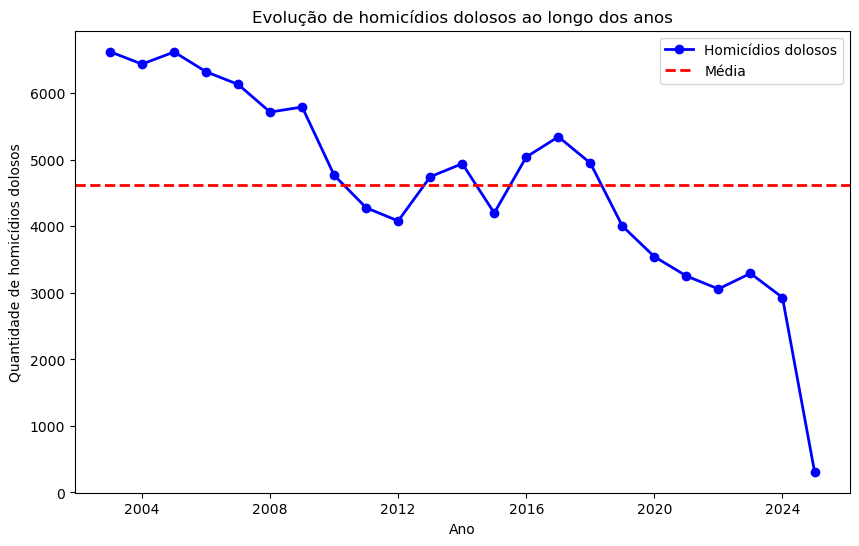

In [ ]:
'''Crie um gráfico de linha mostrando a evolução de hom_doloso ao longo dos anos (ano).'''

'''
marker='o': Define o estilo do marcador que será usado para marcar os pontos de dados no gráfico. 
Neste caso, 'o' representa um círculo. No seu código, parece que há um erro de digitação com '0', que deve ser 'o'.

color='b': Define a cor da linha do gráfico. 'b' representa a cor azul.

linestyle='-': Define o estilo da linha do gráfico. '-' representa uma linha sólida.

linewidth=2: Define a largura da linha do gráfico. 2 representa uma linha com espessura de 2 pontos.
'''

evolucao_hom_doloso = baseDP.groupby('ano')['hom_doloso'].sum()
media_hom_doloso = evolucao_hom_doloso.mean()

plt.figure(figsize=(10,6))
plt.plot(evolucao_hom_doloso.index, evolucao_hom_doloso.values, marker='o', color='b', linestyle='-', linewidth=2)
plt.axhline(y=media_hom_doloso, color='r', linestyle='--', linewidth=2, label='Média')

plt.title("Evolução de homicídios dolosos ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Quantidade de homicídios dolosos")
plt.legend(['Homicídios dolosos', 'Média'])

plt.show()

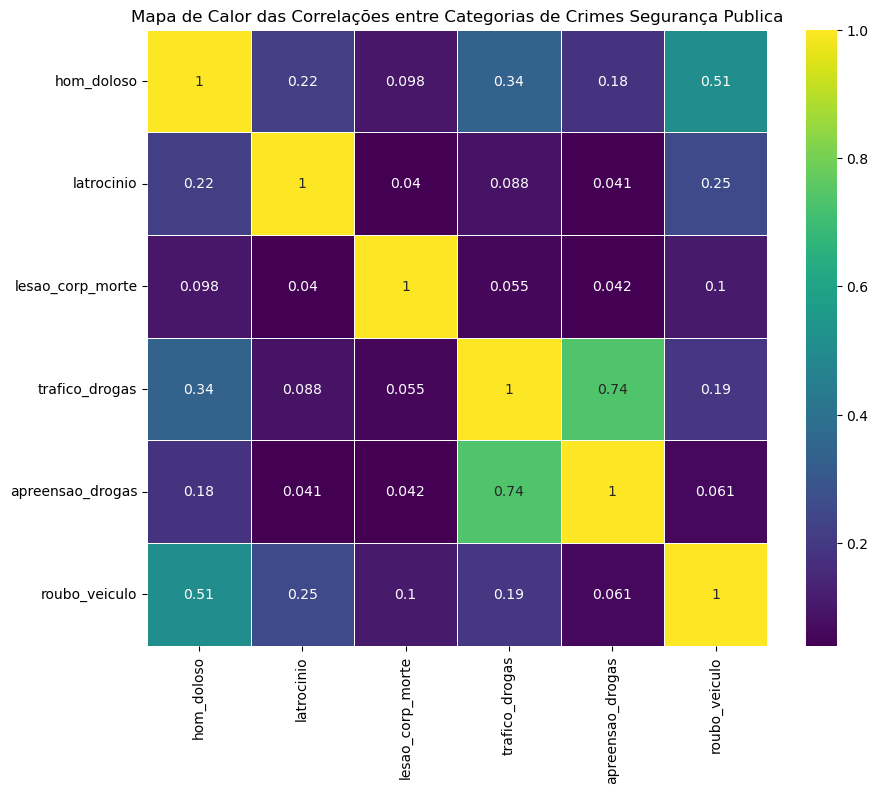

In [102]:
'''Crie um mapa de calor (heatmap) para visualizar a correlação entre as principais categorias de crimes.'''

correlacao = baseDP[['hom_doloso', 'latrocinio', 'lesao_corp_morte','trafico_drogas', 'apreensao_drogas', 'roubo_veiculo']].corr()

sns.set_palette("viridis")

plt.figure(figsize=(10, 8))
sns.heatmap(correlacao, annot=True, cmap='viridis', linewidths=0.5)

plt.title('Mapa de Calor das Correlações entre Categorias de Crimes Segurança Publica')
plt.show()

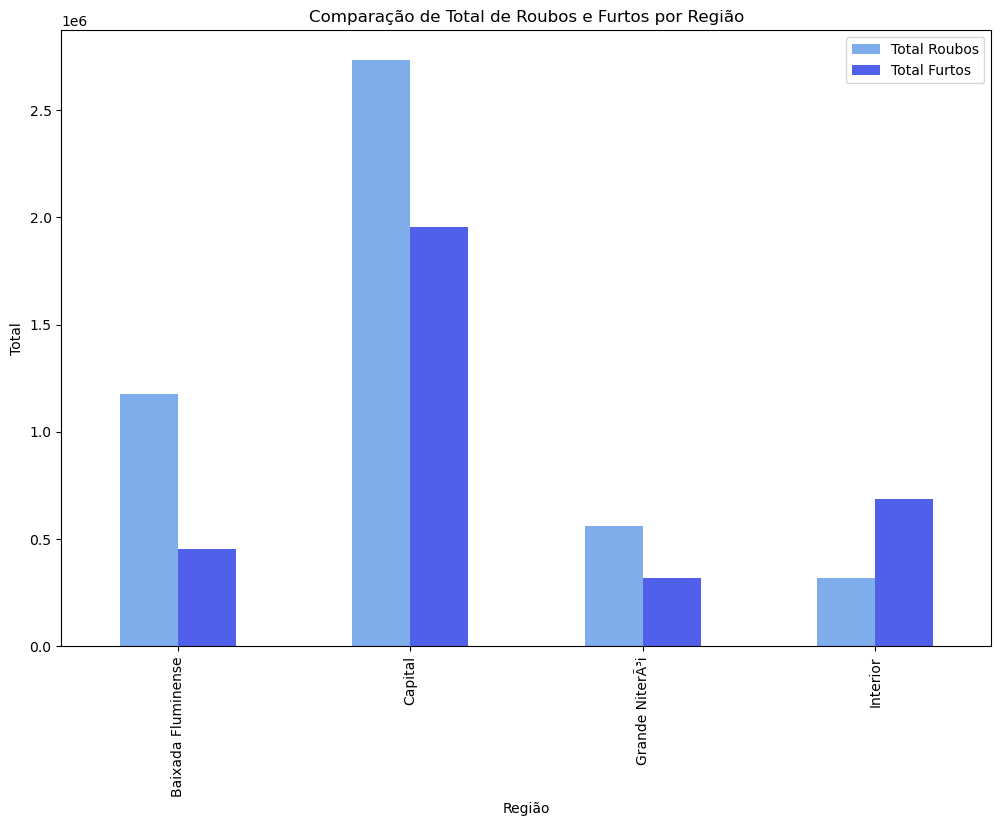

In [ ]:
'''Faça um gráfico de barras comparando total_roubos e total_furtos por região (regiao).'''

comparacao_roubos_furtos_regiao = baseDP.groupby('regiao')[['Todos_roubos', 'Todos_furtos']].sum()

sns.set_palette("viridis")

comparacao_roubos_furtos_regiao.plot(kind='bar', figsize=(12, 8), color=['#7FACEA', '#5060EA'])

plt.title('Comparação do Total de Roubos e Furtos por Região')
plt.xlabel('Região')
plt.ylabel('Total')
plt.legend(['Total Roubos', 'Total Furtos'])

plt.show()
plt.show()

In [106]:
baseDP.head()

,cisp,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,lesao_corp_morte,...,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,Todos_roubos,Todos_furtos
0,1,2003-01-01,2003-01-01,5,1,Rio de Janeiro,3304557,Capital,0,0,...,21,2,0,0,0,0,578,3,166,169
1,4,2003-01-01,2003-01-01,5,1,Rio de Janeiro,3304557,Capital,3,0,...,15,6,0,1,0,0,441,3,133,115
2,5,2003-01-01,2003-01-01,5,1,Rio de Janeiro,3304557,Capital,3,0,...,47,2,1,0,0,0,637,3,187,216
3,6,2003-01-01,2003-01-01,1,1,Rio de Janeiro,3304557,Capital,6,0,...,26,2,1,0,0,0,473,3,199,90
4,7,2003-01-01,2003-01-01,1,1,Rio de Janeiro,3304557,Capital,4,0,...,10,1,3,0,0,0,147,3,60,35


In [ ]:
'''baseDP.to_csv('baseDP_modificado.csv', index=False)'''